# ipynb/multirm_cls_compare_nofont.ipynb - MultiRM 分类对比(无字体) / MultiRM classification compare (no font)

## 项目背景 / Background
MultiRM 分类对比(无字体)
MultiRM classification compare (no font)

## 功能模块 / Modules
- MultiRM 分类结果对比
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: train_human_multirm.py、inference_multirm_segmented.py
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0



[1] "数据预览:"
# A tibble: 39 × 20
   X     X.1   X.2   X.3   X.4   X.5   X.6   X.7   X.8   X.9   X.10  X.11  X.12 
   <lgl> <lgl> <lgl> <lgl> <lgl> <lgl> <lgl> <lgl> <lgl> <lgl> <lgl> <lgl> <lgl>
 1 NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA   
 2 NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA   
 3 NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA   
 4 NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA   
 5 NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA   
 6 NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA   
 7 NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA   
 8 NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA   
 9 NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA   
10 NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA

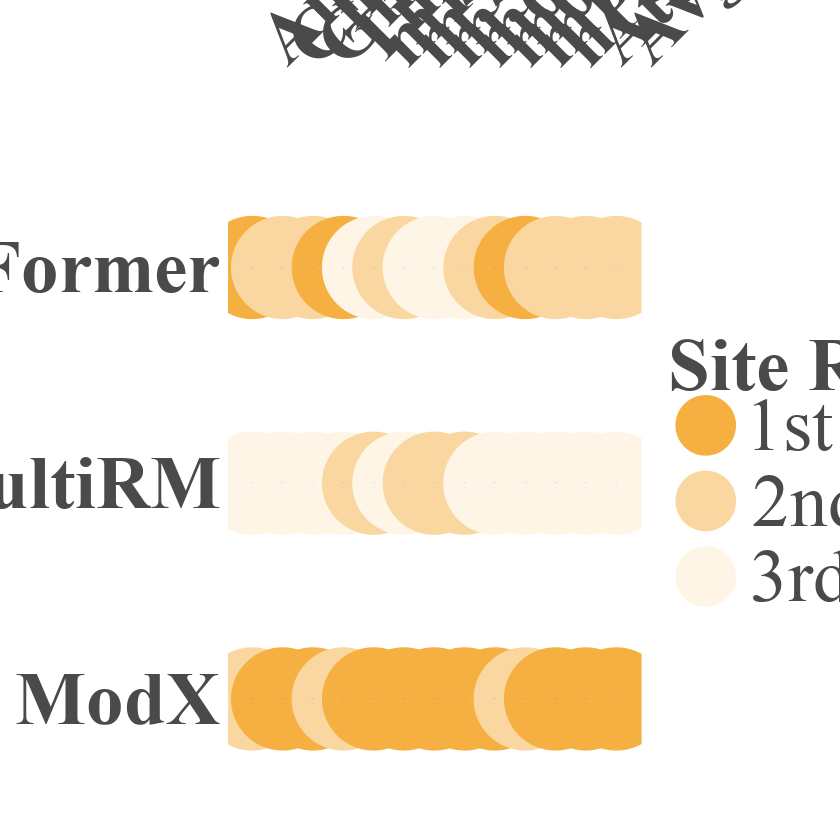

In [14]:
# 1. 安装并加载字体管理包
library(showtext)
library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)

# 2. 注册Times New Roman (如路径不同请自行调整或使用系统默认)
tryCatch({
  font_add("Times New Roman", 
           regular = "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf", 
           bold = "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold.ttf")
  showtext_auto()
}, error = function(e) message("字体加载失败，使用默认字体"))

showtext_opts(dpi = 300)

# 统一字体大小
font_size <- 18

# --- 数据读取与处理 ---
# 读取multirm_aucb_comp.csv数据
data_file <- "multirm_loc_comp/multirm_aucb_comp.csv"

# 读取数据，指定header = TRUE
df_raw <- read.csv(data_file, header = TRUE)

# 只取前12列（位点数据）
site_cols <- c("Am", "Cm", "Gm", "Tm", "m1A", "m5C", "m5U", "m6A", "m6Am", "m7G", "hPsi", "Atol")

# 获取非空行（排除空行）
df_data <- df_raw[1:3, ]  # 取前3行有效数据

# 添加模型名称
model_names <- c("ModX", "MultiRM", "RGCNFormer")
df_data$Model <- model_names

# 转换为长格式数据（包括Avg列）
plot_data <- df_data %>%
  pivot_longer(cols = c(all_of(site_cols), "Avg.AUCb"), names_to = "Site", values_to = "AUCb") %>%
  mutate(
    Site = factor(Site, levels = c(site_cols, "Avg.AUCb")),
    Model = factor(Model, levels = model_names)
  )

# --- 在每个位点内部计算排名（按AUCb值排序）---
plot_data <- plot_data %>%
  group_by(Site) %>%
  mutate(Rank = rank(-AUCb, ties.method = "first")) %>%
  ungroup()

# 打印数据检查
print("数据预览:")
print(plot_data)

# --- 定义颜色深度（按排名）---
rank_palette <- c(
  "1" = "#F5B041",  # 明亮的金色 (最佳)
  "2" = "#FAD7A0",  # 中等浅橙色
  "3" = "#FEF5E7"   # 极浅橙色
)

# --- 绘图 ---
p1 <- ggplot() +
  # 绘制圆圈：所有圆圈固定大小相同
  geom_point(data = plot_data, aes(x = Site, y = Model, color = as.factor(Rank)), size = 28) +
  
  # 绘制数值文本：保留两位小数，截断而非四舍五入
  geom_text(data = plot_data, aes(x = Site, y = Model, label = floor(AUCb * 100) / 100), 
            size = 0, fontface = "bold", family = "Times New Roman", color = "#4A4B4B") +
  
  # 颜色映射设置
  scale_color_manual(name = "Site Rank", values = rank_palette, labels = c("1st", "2nd", "3rd")) +
  
  # 辅助设置
  scale_x_discrete(position = "top", expand = expansion(add = c(0.8, 0.8))) +
  scale_y_discrete(expand = expansion(add = c(0.5, 0.5))) +
  theme_minimal() +
  theme(
    text = element_text(family = "Times New Roman", size = font_size),
    axis.text.x = element_text(size = font_size, face = "bold", color = "#4A4A4A", angle = 45, hjust = 0),
    axis.text.y = element_text(size = font_size, face = "bold", color = "#4A4A4A"),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_rect(fill = "white", color = NA),
    plot.background = element_rect(fill = "white", color = NA),
    legend.position = "right",
    legend.title = element_text(size = font_size, face = "bold", color = "#4A4A4A"),
    legend.text = element_text(size = font_size, color = "#4A4A4A"),
    plot.margin = margin(20, 20, 20, 20)
  ) +
  
  # 图例设置
  guides(
    color = guide_legend(
      override.aes = list(size = 16),
      label.theme = element_text(size = font_size, family = "Times New Roman"),
      order = 1,
      title.theme = element_text(size = font_size, family = "Times New Roman")
    )
  )

# --- 保存图片 ---
dir.create("png3", showWarnings = FALSE)
ggsave("png3/multirm_aucb_compare.pdf", p1, width = 16, height = 5, dpi = 300)
print(p1)

# --- 额外统计信息 ---
cat("\n=== 各修饰位点最佳模型 ===\n")
best_per_site <- plot_data %>%
  group_by(Site) %>%
  slice_max(AUCb, n = 1) %>%
  select(Site, Model, AUCb)
print(best_per_site)

cat("\n=== 各模型胜出位点数 ===\n")
best_per_site %>%
  count(Model, name = "Wins") %>%
  print()
